## Introducción

La cadena de gimnasios Model Fitness está desarrollando una estrategia de interacción con clientes basada en datos analíticos.

Uno de los problemas más comunes que enfrentan los gimnasios y otros servicios es la pérdida de clientes. En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. Por lo que en este proyecto se analizarán y elaborará una estrategia de retención de clientes.

## Información general 

In [14]:
# Librerías de terceros
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## librerías para modelos de predicción
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [15]:
# cargar las bases de datos
gym_churn = pd.read_csv('gym_churn_us.csv')

In [16]:
# imprimir las primeras filas del dataframe
gym_churn.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [17]:
# imprimir información general del dataframe
gym_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [18]:
# imprimir datos estadísticos del dataframe
gym_churn.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


### Conclusiones
* No hay datos ausentes en el dataframe 'gym_churn'.
* Los nombres de las columnas no siguen el formato snake_case.
* El promedio de edad de los clientes del gimansio es de 29 años, los cuales incurren en gastos adicionales de $ 146.94 en promedio.

## Preprocesamiento de datos

### Estilo de encabezado

Dado que se identificó que varias columnas del dataframe no siguen el formato snake_case, se procede a modificarlas para que sí lo cumplan.

In [20]:
# lista de apoyo donde se colocarán todos los nuevos nombres de las columnas
new_col_names = []

for old_name in gym_churn.columns:
    # pasar todas las letras en minúsculas
    name_lowered = old_name.lower()
    # agregar el nuevo nombre a la lista de nuevos nombres de columna
    new_col_names.append(name_lowered)

# reemplazar los nombres anteriores con los nuevos
gym_churn.columns = new_col_names

# verificar el cambio de nombres de las columnas
print(gym_churn.columns)

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')


### Valores ausentes 

No se encontraron valores ausentes en el dataframe 'gym_churn'

In [21]:
# imprimir información general del dataframe
gym_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

### Duplicados (explícitos e implícitos)

In [22]:
# contar duplicados explícitos
gym_churn.duplicated().sum()

np.int64(0)

No se encontraron duplicados explícitos

In [23]:
# contar duplicados implícitos
for column in gym_churn.columns:
    print(f'Duplicados implícitos en {column}: {gym_churn[column].duplicated().sum()}')

Duplicados implícitos en gender: 3998
Duplicados implícitos en near_location: 3998
Duplicados implícitos en partner: 3998
Duplicados implícitos en promo_friends: 3998
Duplicados implícitos en phone: 3998
Duplicados implícitos en contract_period: 3997
Duplicados implícitos en group_visits: 3998
Duplicados implícitos en age: 3977
Duplicados implícitos en avg_additional_charges_total: 0
Duplicados implícitos en month_to_end_contract: 3988
Duplicados implícitos en lifetime: 3971
Duplicados implícitos en avg_class_frequency_total: 87
Duplicados implícitos en avg_class_frequency_current_month: 180
Duplicados implícitos en churn: 3998


Se encontraron duplicados implícitos, sin embargo, no debe ser un motivo de preocupación por la naturaleza de los datos.

### Tipos y optimización de datos
Todas las columnas del dataframe tienen tipos de datos adecuados para la información que almacenan. El único que podría cambiar es la columna 'month_to_end_contract', el cual contiene datos de tipo flotante, cuando en realidad contiene únicamente datos enteros. Se podría hacer la conversión de datos pero, dado que no representan un cambio significante para el uso de memoria, no se procederá a hacer el cambio en el tipo de datos.

In [24]:
gym_churn['month_to_end_contract'].unique()

array([ 5., 12.,  1.,  6.,  3., 10., 11.,  9.,  4.,  7.,  8.,  2.])

## Conclusiones
* Se pasaron todas las letras de los encabezados del dataframe 'gym_churn' para que siguieran el formato snake_case.
* No se encontraron valores ausentes en el dataframe.
* No se encontraron duplicados explícitos. Sin embargo, sí se encontraron duplicados implícitos, pero no se procedió a hacer alguna modificación a estos, pues no representan ningún problema para el análisis y pronósticos posteriores.
* Todas las columnas del datframe contienen el tipo de dato adecuado para la información que contienen.
* Se identificó que la columna 'month_to_end_contract' contenía únicamente datos enteros pero con tipo de datos flotantes. No se procedió a cambiar el tipo de datos, ya que no representa un cambio significante en el uso de la memoria.

## Análisis exploratorio de datos (EDA)

### Valores promedio y desviación estándar

Se procede a observar el dataset, y si contiene alguna característica ausente. Se estudian los valores promedio y la desviación estándar utilizando el método describe()).

In [25]:
# obtener información general del dataframe
gym_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   near_location                      4000 non-null   int64  
 2   partner                            4000 non-null   int64  
 3   promo_friends                      4000 non-null   int64  
 4   phone                              4000 non-null   int64  
 5   contract_period                    4000 non-null   int64  
 6   group_visits                       4000 non-null   int64  
 7   age                                4000 non-null   int64  
 8   avg_additional_charges_total       4000 non-null   float64
 9   month_to_end_contract              4000 non-null   float64
 10  lifetime                           4000 non-null   int64  
 11  avg_class_frequency_total          4000 non-null   float

In [26]:
# obtener datos estadísticos del dataframe
gym_churn.describe()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


El dataframe no tiene características ausentes, y estos a su vez no tienen datos ausentes.

Además, que encontramos en promedio:

* Los usuarios mujeres y hombres se encuentran en una proporción similar, siendo casi el 50% de cada género.
* La mayoría de los usuarios (84%) se encuentra en una ubicación cercana al gimnasio.
* Casi la mitad de los usuarios (48%) provienen de asociaciones con empresas.
* Solo el 30% de los usuarios se inscribieron con oferta de 'trae a un amigo'.
* Casi todos los usuarios (90%) proporcionaron su teléfono.
* Se contrata en promedio 5 meses. Aunque suele variar mucho de usuario a usuario.
* Casi la mitad de los usuarios (41%) participa en sesiones grupales.
* La edad promedio de los usuarios son 29 años. No es muy variable de usuario a usuario.
* En promedio recurren en gastos adicionales de $ 146.94.
* En promedio tienen una antigüedad de 4 meses.
* Visitan el gimnasio 2 veces a la semana.

### Valores medios por estatus de cancelación

Se procede a observar los valores medios de las características en dos grupos: para las personas que se fueron (cancelación) y para las que se quedaron. Se utiliza el método groupby().

In [27]:
# agrupar por 'churn' y obtener el promedio
mean_data_churn = gym_churn.groupby(['churn']).mean()
mean_data_churn

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Encontramos que, en promedio, quienes cancelaron:

* Se encontraban en una ubicación más lejana que aquellos que permanecieron.
* Formaban parte de una asociación con la empresa en la que trabajan en menor cantidad que aquellos que permanecieron.
* Se registraron con oferta de 'trae a un amigo' en menor proporción que aquellos que permanecieron.
* Dieron su teléfono en la misma proporción que aquellos que permanecieron.
* Contrataron una menor cantidad de meses que aquellos que permanecieron.
* Participan en sesiones grupales en menor medida que aquellos que permanecieron.
* Tienen menos edad que aquellos que permanecieron.
* Gastaron menos cosas adicionales que aquellos que permanecieron.
* Tenían un mes para que se acabara su contrato, en comparación con quienes permanecieron que tenían 5 meses para que terminara su contrato.
* Tenían una antigüedad menor (1 mes) que aquellos que permanecieron (5 meses).
* En toda su antigüedad y en el mes actual, asistieron menos veces a la semana al gimnasio (1.5 veces y 1 vez, respectivamente) a comparación de quienes permanecieron (2 veces y 2 veces, respectivamente).

### Distribución de características por estatus de cancelación
Se trazan histogramas de barras y distribuciones de características para aquellas personas que se fueron (cancelación) y para las que se quedaron.

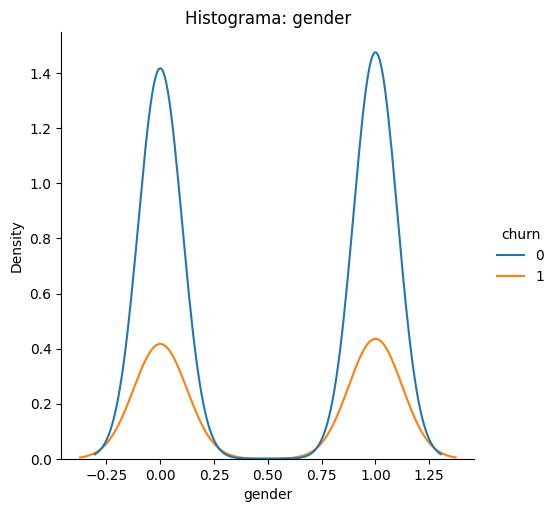

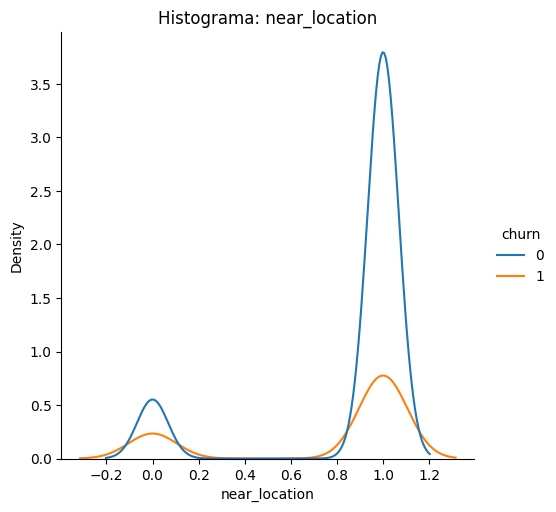

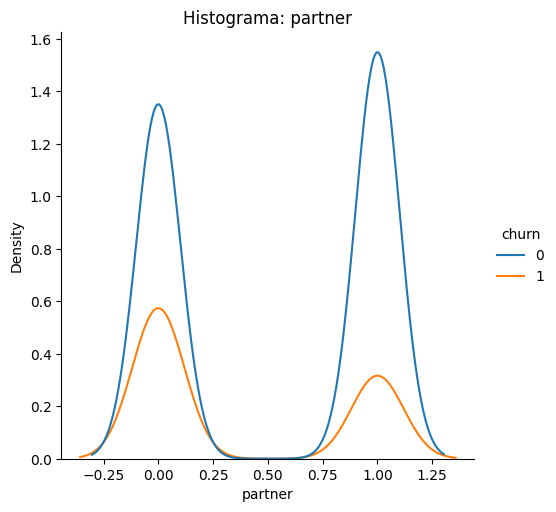

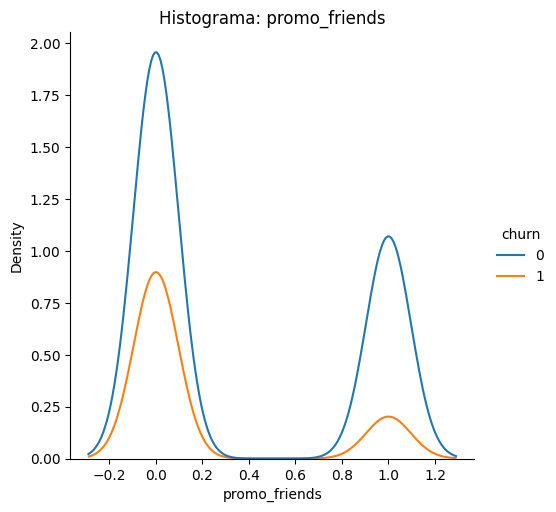

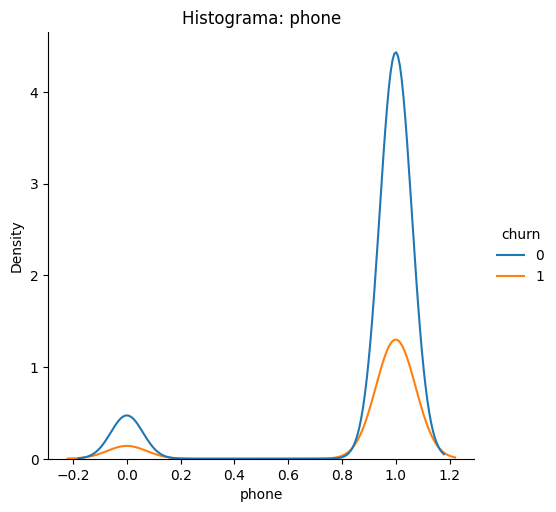

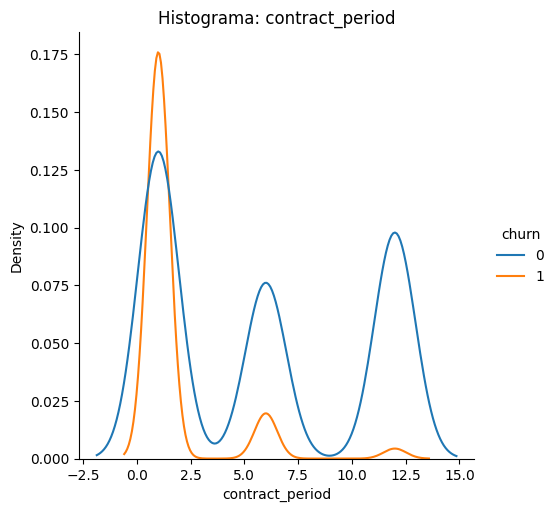

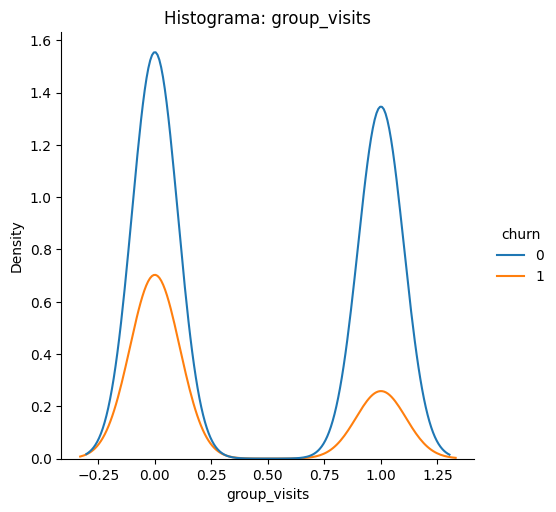

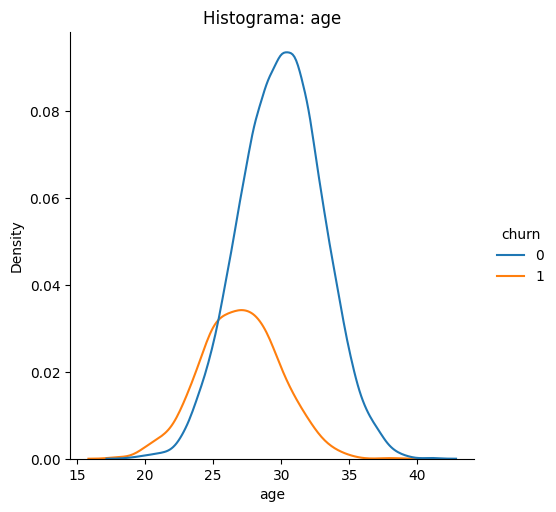

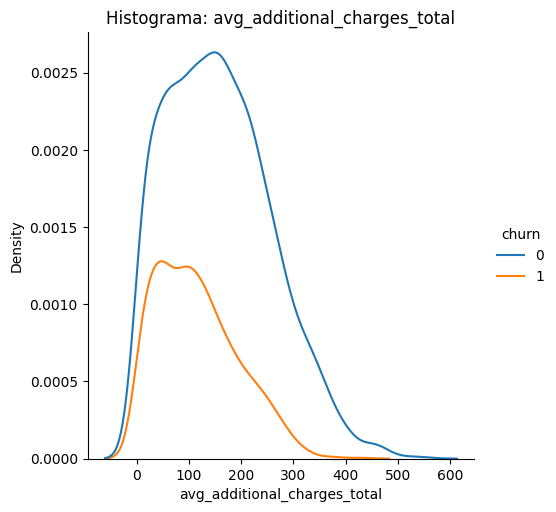

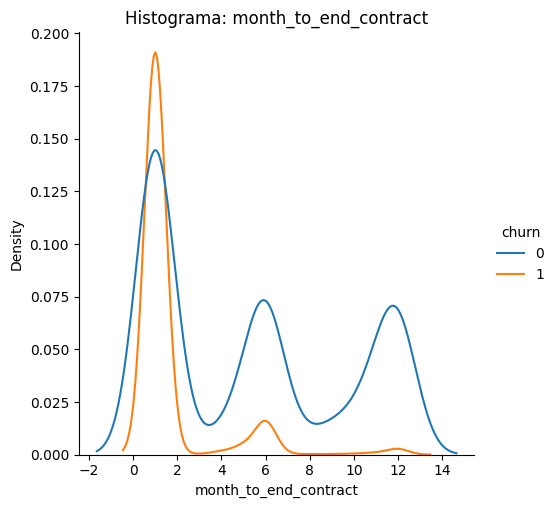

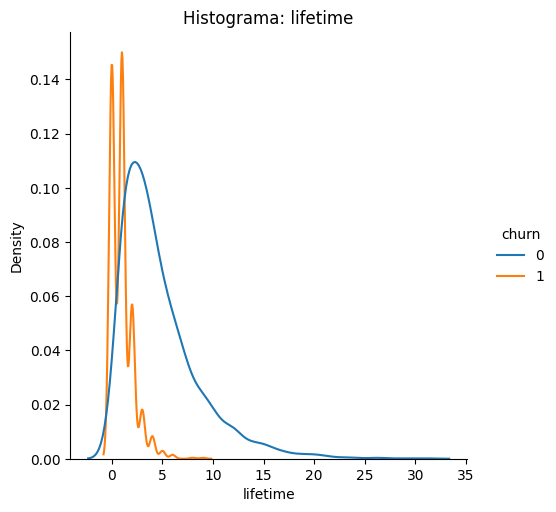

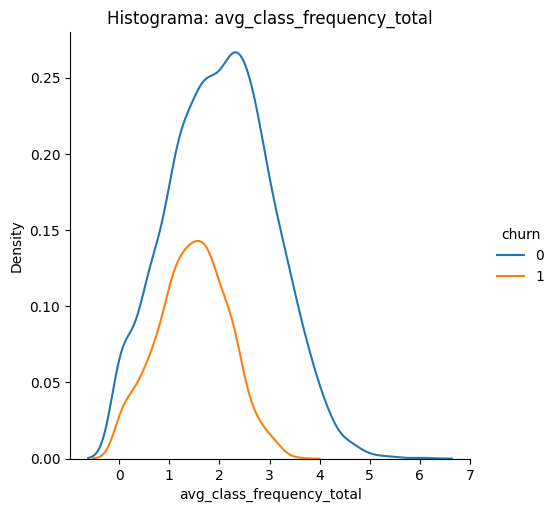

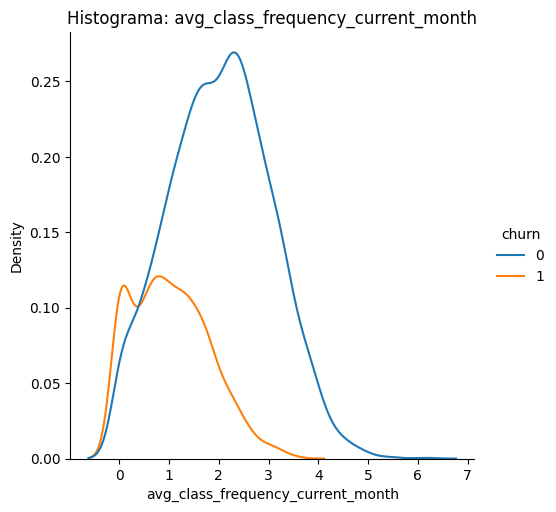

In [28]:
for column in gym_churn.columns[:-1]:
    sns.displot(data=gym_churn, x=column, hue='churn', kind="kde")
    plt.title(f'Histograma: {column}')
    plt.show()

Encontramos lo siguiente sobre las distribuciones para las características que nos interesan:

* 'gender': es similar para quienes cancelaron y quienes no.
* 'near_location': es similar para quienes cancelaron y quienes no.
* 'partner': quienes cancelaron tienen casi la misma distribución entre quienes tienen asociación por parte de su empresa, que quienes no. Mientras que quienes cancelaron tienden a no tener asociación por parte de su empresa.
* 'promo_friends': es similar entre quienes cancelaron y quienes no.
* 'phone': es similar entre quienes cancelaron y quienes no.
* 'contract_period': quienes cancelaron suelen contratar en su mayoría 1 mes, al igual que quienes no cancelan. Sin embargo, quienes permanecen suelen también contratar por periodos de 1 año y 6 meses, mientras que los que cancelan en su minoría contratan en dichos periodos.
* 'group_visits': la distribución entre quienes toman sesiones grupales o no es similar para quienes permanencen, mientras que para los que cancelan la distribución de las sesiones grupales tiende a ser que no asisten a estas sesiones.
* 'age': quienes permanecen tienen una edad mayor que quienes cancelan (30 años aprox. vs. 27 años aprox.).
* 'avg_additional_charges_total': tienen una distribución similar que parecen tener una asimetría a la derecha. Sin embargo, los gastos para quienes permanecen son mayores que para quienes cancelan.
* 'month_to_end_contract': quienes cancelan suelen estar en su mayoría a un mes para que termine su contrato en mayor cantidad que aquellos que no cancelan. Cabe destacar que para aquellos que cancelan, a la minoría le quedan de 6 a 12 meses para que termine su contrato.
* 'lifetime': la dsitribución tanto para los que cancelan como para los que permanecen tiene asimetría hacia la derecha, donde para aquellos que cancelan esta asimetría es más evidente, pues parece ser que aquellos que tienen menos tiempo de antigüedad tienen más probabilidades de cancelar.
* 'avg_class_frequency_total': ambas distribuciones, tanto de quienes cancelan como los que no, es similar con una ligera asimetría a la derecha. La mayoría de quienes permanencen asisten en promedio a más veces al gimnasio en todo el periodo de su antiüedad que aquellos que cancelan.
* 'avg_class_frequency_current_month': la distribución para aquellos que no cancelan parece tener una ligera asimetría a la derecha, mientras que para la distribución de los que cancelan tiene esta asimetría más marcada. Igualmente obsercamos que la mayoría de quienes permanecen asisten en primedio más veces al gimnasio en el mes actual que aquellos que cancelan.

### Matriz de correlación

Se crea una matriz de correlación y se muestra.

<Axes: >

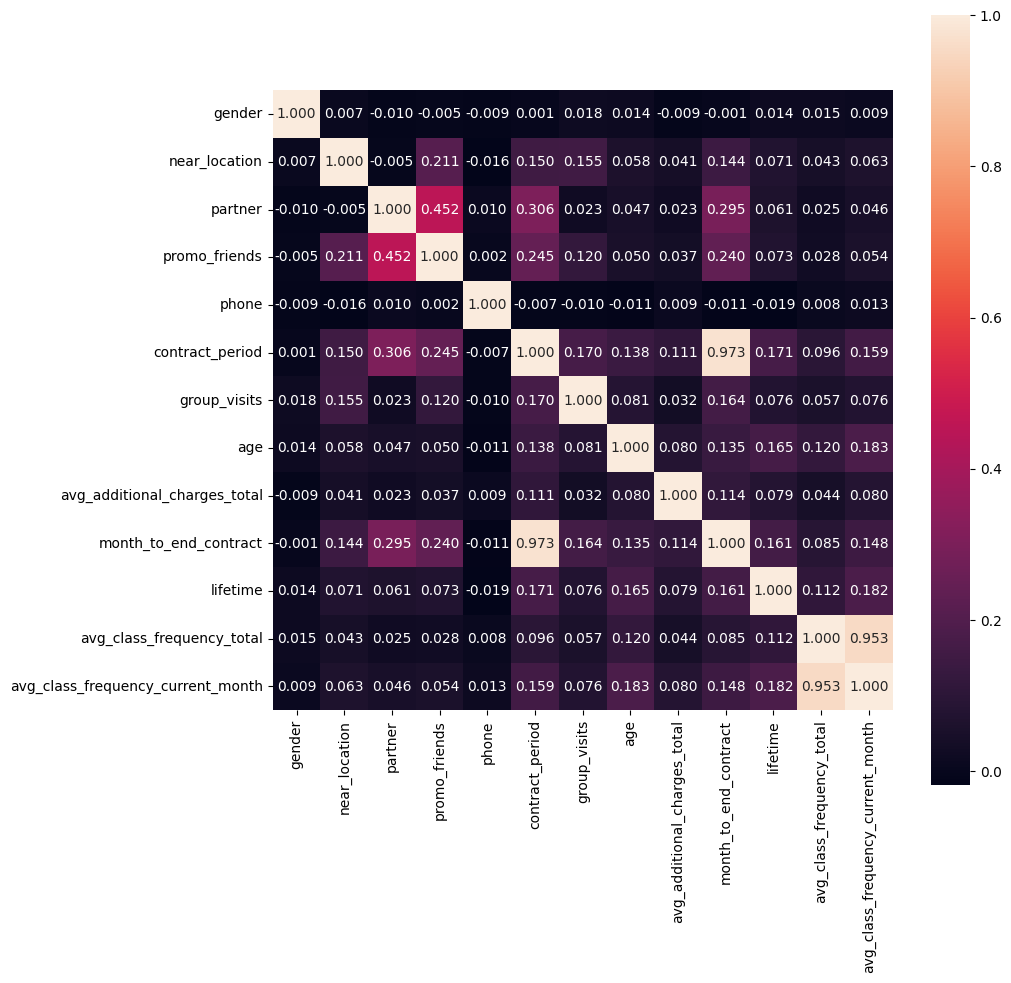

In [29]:
cm = gym_churn.iloc[:, :-1].corr()
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot = True, square=True, fmt=".3f")

* Las características 'month_to_end_contract' y 'contract_period' están altamente correlacionadas (0.9), lo cual podría generar problemas de multicolinealidad.
* Las características 'partner' y 'promo_friends' tienen la siguiente correlación más alta, siendo de 0.45. Las siguientes destacables son 'partner' y 'contract_period' con 0.306 y 'partner' y 'month_to_end_contract' con 0.295.

### Conclusiones
Se encontró que:

* La mayoría de los usuarios que cancelaron su suscripción se encontraban en una ubicación más lejana al gimnasio en comparación con aquellos que permanecieron. Esto sugiere que la proximidad es un factor importante para la retención de los clientes.
* Los usuarios que tenían asociaciones corporativas con el gimnasio tendían a cancelar menos. Aquellos que no contaban con este tipo de asociación mostraron una mayor propensión a cancelar, lo que indica que las asociaciones con empresas podrían ser una estrategia efectiva para la retención.
* Los clientes que cancelaron su suscripción, en su mayoría, tenían contratos más cortos (principalmente de 1 mes). En contraste, aquellos que permanecieron tenían contratos de mayor duración (6 meses o 1 año). Esto sugiere que los contratos más largos pueden estar asociados con una mayor retención.
* La participación en sesiones grupales también parece ser un factor relevante. Los usuarios que permanecen en el gimnasio tienden a participar en sesiones grupales en mayor medida que aquellos que cancelan, lo que sugiere que estas actividades podrían estar vinculadas a una mayor lealtad.
* La frecuencia de visitas, tanto a lo largo del tiempo como en el mes actual, es mayor entre los clientes que no cancelan. Aquellos que asistieron más veces por semana mostraron una mayor probabilidad de permanecer inscritos, lo que implica que una mayor participación activa en el gimnasio está relacionada con una menor tasa de cancelación.
* Los clientes que permanecieron en el gimnasio tienden a ser ligeramente mayores (aproximadamente 30 años) y gastan más en servicios adicionales en comparación con aquellos que cancelaron (27 años y menores gastos). Esto sugiere que la edad y el nivel de gasto pueden ser indicadores de compromiso y lealtad.
* Los clientes con menor antigüedad (1 mes en promedio) y con contratos próximos a vencer (1 mes restante) son más propensos a cancelar.
* Las características 'month_to_end_contract' y 'contract_period' están altamente correlacionadas (0.9), lo que sugiere que se debe tener cuidado con la multicolinealidad al desarrollar modelos predictivos.

## Modelo para predecir la cancelación de los usuarios
1. Se crea un modelo de clasificación binaria para clientes donde la característica objetivo es la marcha del usuario o la usuaria el mes siguiente.

2. Se indica el parámetro random_state cuando se dividen los datos y define el algoritmo.

### División de datos en entrenamiento y validación, y escalado de características

Divide los datos en conjuntos de entrenamiento y validación utilizando la función train_test_split().

In [30]:
# dividir los datos en características (la matriz X) y una variable objetivo (y)

# almacena la matriz objeto-característica en la variable,
# después de haber eliminado la columna con la variable objetivo del DataFrame
X = gym_churn.drop('churn', axis = 1) 

# almacena la columna con el valor de la variable objetivo en la variable
y = gym_churn['churn']

Dividimos los datos de entrenamiento y prueba en una proporción 80/20.

In [31]:
# dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Procedemos a escalar las características. Realizar el escalado luego de separar los sets de datos nos permite evitar el data leakage en los modelos.



In [32]:
# Entrenar StandardScaler en el conjunto de entrenamiento
scaler = StandardScaler()
scaler.fit(X_train)

# transformar conjuntos de entrenamiento y de prueba
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

### Entrenamiento de modelos
Entrenamos el modelo en el set de entrenamiento con dos métodos:

1. regresión logística;
2. bosque aleatorio.
#### Entrenamiento de modelo de regresión logística

In [33]:
# definir el algoritmo para el modelo de regresión logística
lr_model = LogisticRegression(random_state=0)

# entrenar el modelo 
lr_model.fit(X_train_st, y_train)

# utilizar el modelo entrenado para hacer previsiones
lr_predictions = lr_model.predict(X_test_st)
lr_probabilities = lr_model.predict_proba(X_test_st)[:,1]

#### Entrenamiento del modelo de bosque aleatorio

In [34]:
# definir el algoritmo para el nuevo modelo de random forest
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 0)

# entrenar el modelo de random forest
rf_model.fit(X_train_st, y_train)

# utilizar el modelo entrenado para hacer previsiones
rf_predictions = rf_model.predict(X_test_st)
rf_probabilities = rf_model.predict_proba(X_test_st)[:,1]

#### Evaluación de modelos por exactitud, precisión y recall
Evaluamos la exactitud, precisión y recall para ambos modelos utilizando los datos de validación, y los utilízamos para comparar los modelos y determinar qué modelo dio mejores resultados.

In [35]:
# muestra todas las métricas estudiadas para la predicción resultante

# regresión logística
print('REGRESIÓN LOGÍSTICA')
print('Exactitud: {:.2f}'.format(accuracy_score(y_test, lr_predictions)))
print('Precisión: {:.2f}'.format(precision_score(y_test, lr_predictions)))
print('Recall: {:.2f}'.format(recall_score(y_test, lr_predictions)))
print()

# bosque aleatorio
print('BOSQUE ALEATORIO')
print('Exactitud: {:.2f}'.format(accuracy_score(y_test, rf_predictions)))
print('Precisión: {:.2f}'.format(precision_score(y_test, rf_predictions)))
print('Recall: {:.2f}'.format(recall_score(y_test, rf_predictions)))

REGRESIÓN LOGÍSTICA
Exactitud: 0.92
Precisión: 0.85
Recall: 0.83

BOSQUE ALEATORIO
Exactitud: 0.92
Precisión: 0.84
Recall: 0.81


Observamos que la métrica de exactitud es mayor para la regresión logística que para el bosque aleatorio. Sin embargo, debemos recordar que esta métrica sólo funciona para las clases que están equilibradas, lo cual no se cumple para las cancelaciones al servicio del gimnasio, donde aproximadamente el 27% de los usuarios caen.

Igualmente, obsercamos que, para la regresión logística, la precisión y recall es mayor que para el bosque aleatorio. De estas dos métricas, destaca la precición, pues el buscar a personas que van a cancelar la suscripción al gimnasio cuesta dinero.

Por estas razones, se concluye que el modelo de regresión logística dio mejores resultados para las predicciones.

Observamos las importancias de las características.

In [36]:
feature_weights = lr_model.coef_
feature_weights

array([[-0.01300993, -0.07598346, -0.08136891, -0.27573057,  0.00448274,
        -0.70588538, -0.39402357, -1.09236955, -0.55235042, -0.54637972,
        -3.84681859,  3.30838184, -4.46148249]])

In [37]:
weight_0 = lr_model.intercept_
weight_0

array([-3.70800296])

In [38]:
importances = rf_model.feature_importances_
importances

array([0.01242526, 0.00942085, 0.01228455, 0.01205345, 0.0061919 ,
       0.06596372, 0.01565161, 0.11912869, 0.09147294, 0.06885504,
       0.27649949, 0.12988274, 0.18016975])

Se encontró que variables como el promedio de frecuencia de veces que se asisten al gimnasio (total como del mes acutal), el tiempo de antigüedad del cliente, la edad, y el periodo de contrato (contratado y restante) son factores importantes que determinan la continuidad de un cliente en el gimnasio.

### Clústeres de usuarios/as
Dejamos de lado la columna con datos sobre la cancelación e identificamos los clústeres de objetos (usuarios/as):

In [39]:
# eliminar columna de cancelación
clusters_data = gym_churn.drop('churn', axis = 1)

### Estandarización de datos
Estandariza los datos.

In [40]:
# entrenar StandardScaler
scaler = StandardScaler()
scaler.fit(clusters_data)

# transformar conjunto de datos
gym_churn_st = scaler.transform(clusters_data)

### Dendograma
Utilizamos la función linkage() para crear una matriz de distancias basada en la matriz de características estandarizada y trazamos un dendrograma. Utilizamos el gráfico resultante para estimar el número de clústeres que podemos destacar.

Nota: renderizar el dendrograma puede llevar tiempo.

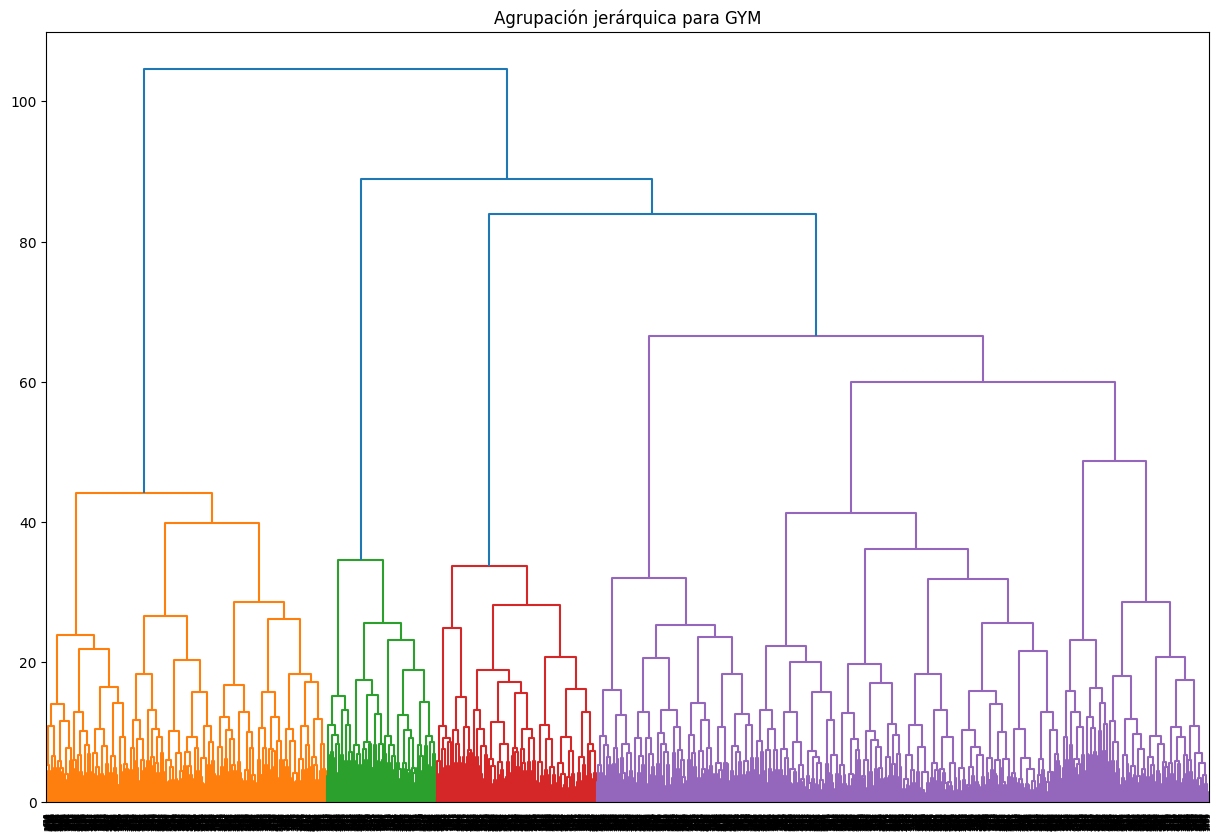

In [41]:
# obtener matriz de distancias
linked = linkage(gym_churn_st, method = 'ward')

# graficar dendograma
plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top')
plt.title('Agrupación jerárquica para GYM')
plt.show()

Observamos que el número óptimo de clústeres sugerido es 4.


### Predicción de los clústeres de clientes
Entrenamos el modelo de clustering con el algortimo K-means y predecimos los clústeres de clientes. Dejamos que el número de clústeres sea n=5 con base en el gráfico del paso anterior.

In [77]:
# definir el modelo k_means con 5 clústeres
km = KMeans(n_clusters=5)

# predicir los clústeres de clientes
labels = km.fit_predict(gym_churn_st)

In [78]:
# almacenar etiquetas de clúster en el campo del conjunto de datos
gym_churn['cluster_km'] = labels

### Valores medios de características para los clústeres
Observamos los valores medios de característica para los clústeres.

In [79]:
# obtiene las estadísticas de los valores medios de las características por clúster
gym_churn.groupby(['cluster_km']).mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster_km,,,,,,,,,,,,,,
0,0.523316,0.862694,0.471503,0.305699,0.0,4.777202,0.427461,29.297927,144.208179,4.466321,3.940415,1.854211,1.723967,0.266839
1,0.483845,1.000000,0.355412,0.242326,1.0,1.962843,0.340065,28.144588,130.918569,1.872375,2.390953,1.233389,0.995856,0.519386
2,0.564858,0.977594,0.343160,0.221698,1.0,2.550708,0.472877,30.122642,161.268043,2.349057,4.916274,2.812928,2.807517,0.074292
3,0.498531,0.960823,0.783546,0.575906,1.0,10.854065,0.539667,29.972576,161.128963,9.920666,4.723800,2.003225,1.996705,0.027424
4,0.497041,0.000000,0.461538,0.078895,1.0,2.378698,0.218935,28.479290,135.631940,2.224852,2.812623,1.662253,1.480228,0.441815


Los valores medios de las características de los clústers suelen distinguirse unos de otros, donde en algunos casos un clúster (o dos clústeres con valores similares) se distinguen del resto. Destaca el valor medio de la característica 'gender', el cual es similar para todos los clústeres.

### Distribuciones de características para los clústeres
Trazamos distribuciones de características para los clústeres.

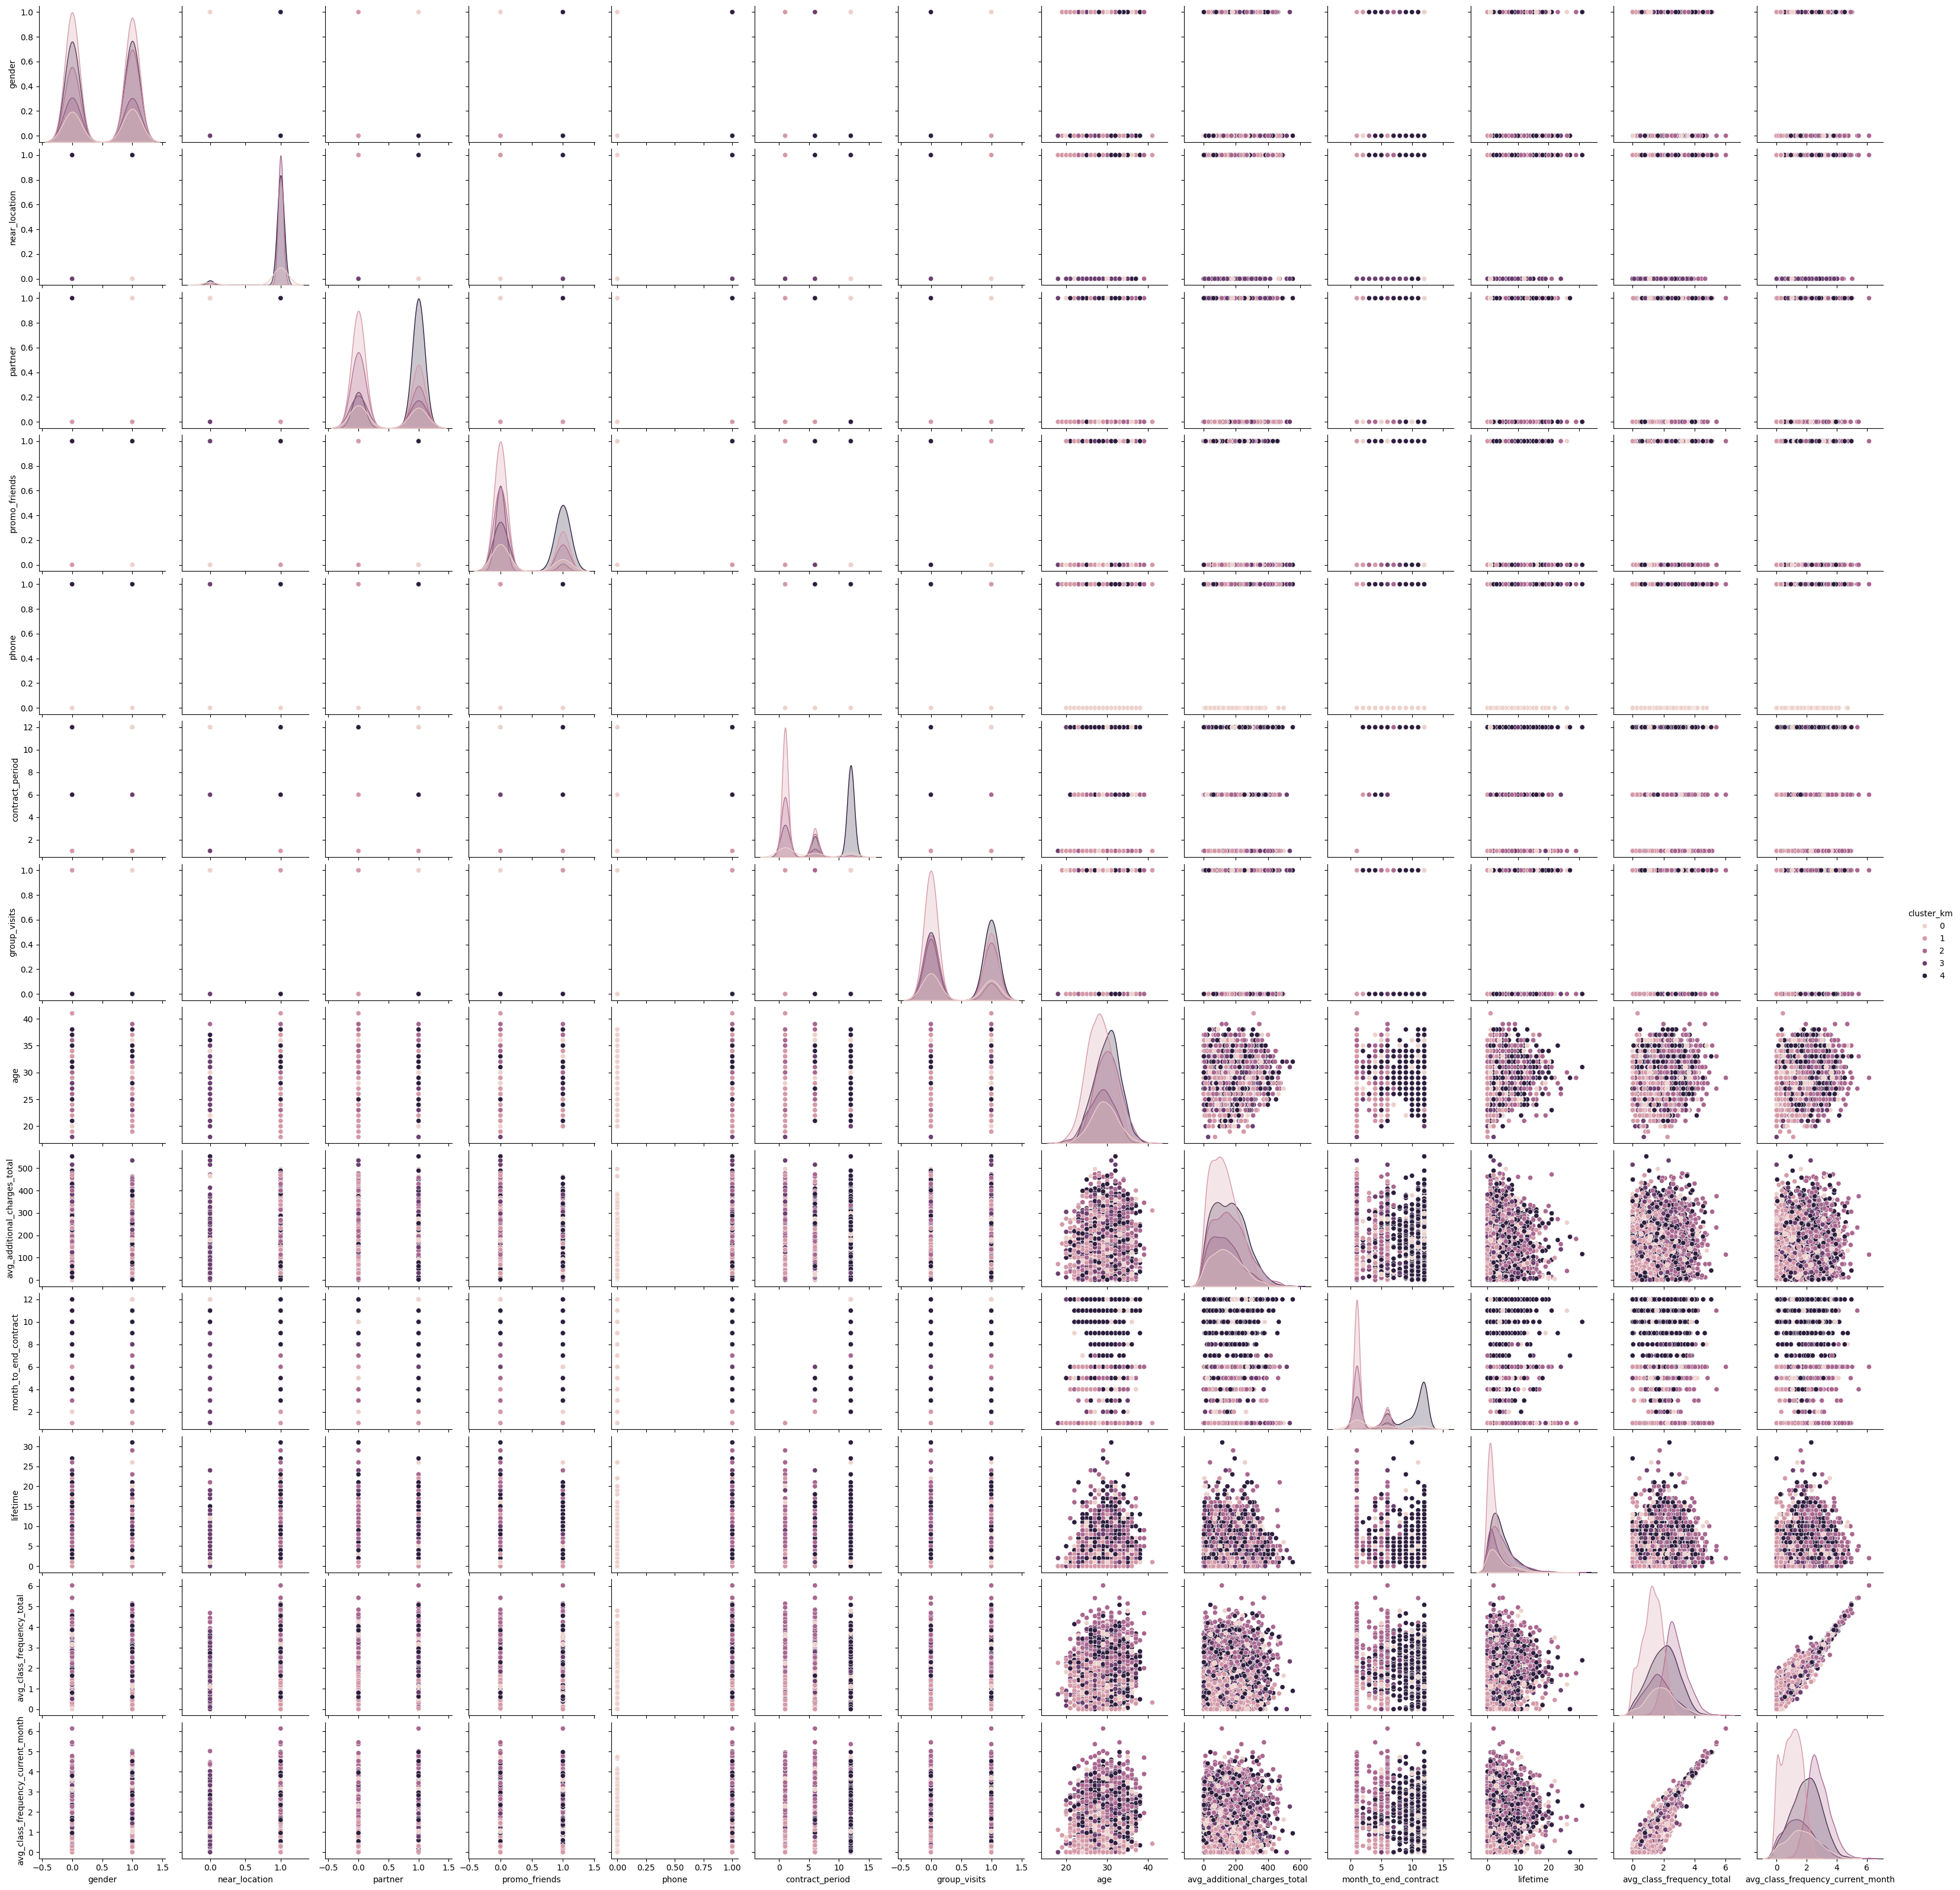

In [52]:
sns.pairplot(hue='cluster_km', data=gym_churn.drop('churn', axis = 1))

Para algunas características, las distribuciones de estas para cada clúster son similares; por ejemplo, para la característica gender. Sin embargo, hay agunas características como 'partner', 'promo_friend', 'contract_period', 'month_to_end_contract', entre otas, cuyas distribuciones para cada clúster difieren de otras.

### Tasa de cancelación para cada clúster
Calculamos la tasa de cancelación para cada clúster utilizando el método groupby().

In [80]:
gym_churn.groupby(['cluster_km'])['churn'].mean().reset_index()

,cluster_km,churn
0,0,0.266839
1,1,0.519386
2,2,0.074292
3,3,0.027424
4,4,0.441815


El clúster que es más propenso a irse es el 2, seguido del 3 y 4. Por lo que los más leales son el 1, seguido del 0. Sí podemos afirmar que la tasa de cancelación para cada clúster es diferente.

# Conclusiones y recomendaciones básicas sobre el trabajo con clientes
Se encontró que variables como el promedio de frecuencia de veces que se asisten al gimnasio (total como del mes acutal), el tiempo de antigüedad del cliente, la edad, y el periodo de contrato (contratado y restante) son factores importantes que determinan la continuidad de un cliente en el gimnasio. Por ello, algunas acciones que se recomiendan son:

* Clasificar al cliente lo más temprano posible dentro de un clúster y proporcionarle promociones que incentiven su permanencia de acuerdo a las características del clúster.
* La primera forma de clasificar al cliente (ya que no contamos con muchos datos al momento de su inscripción), sería clasificarlo de acuerdo a su edad, pues encontramos que las personas más jóvenes son más propensas a abandonar. También otra variable para clasificarlo en este momento sería el periodo de contratación del cliente, donde se pueda dar alguna promoción para extender su suscripción en caso de haber contratado por muy poco tiempo.
* Usar el modelo de predicción y, al identificar a clientes que cancelarán, incentivarlos a quedarse con alguna promoción.